<a href="https://colab.research.google.com/github/Khanbir/Data_analitycs/blob/main/DZ__%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/DATA-ANALITICS_ Pylieva/yulu_bike_sharing_dataset.csv')

In [30]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [31]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [32]:
df.shape

(10886, 19)

In [33]:
print(f"Всього рядків: {df.shape[0]}, Всього колонок: {df.shape[1]}")

Всього рядків: 10886, Всього колонок: 19


Даних 10886 рядків, **19 колонок**.
В кожному рядку сума оренд велосипедів за 1 годину.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


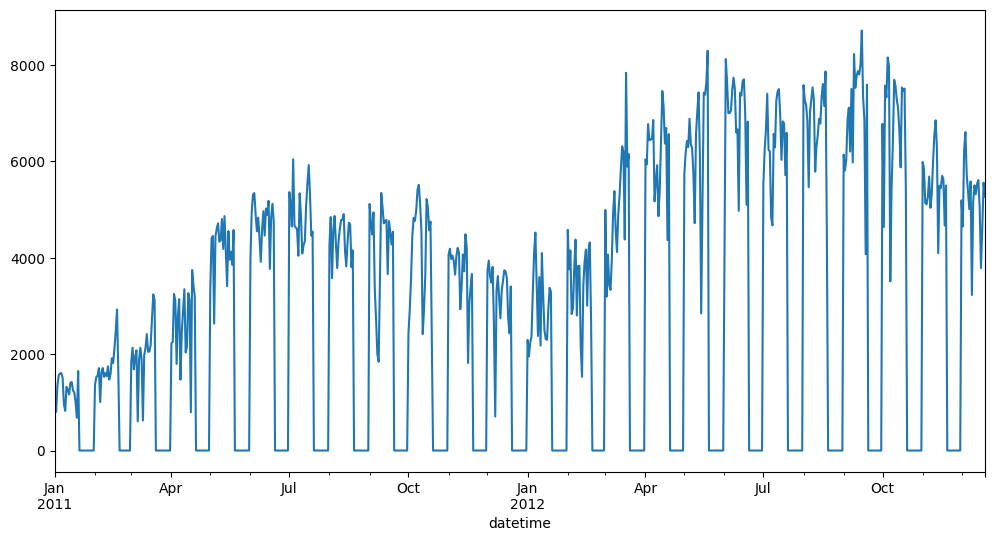

In [34]:
count_day = df['count'].resample('d').sum()
count_day
count_day.plot.line( figsize=(12, 6));

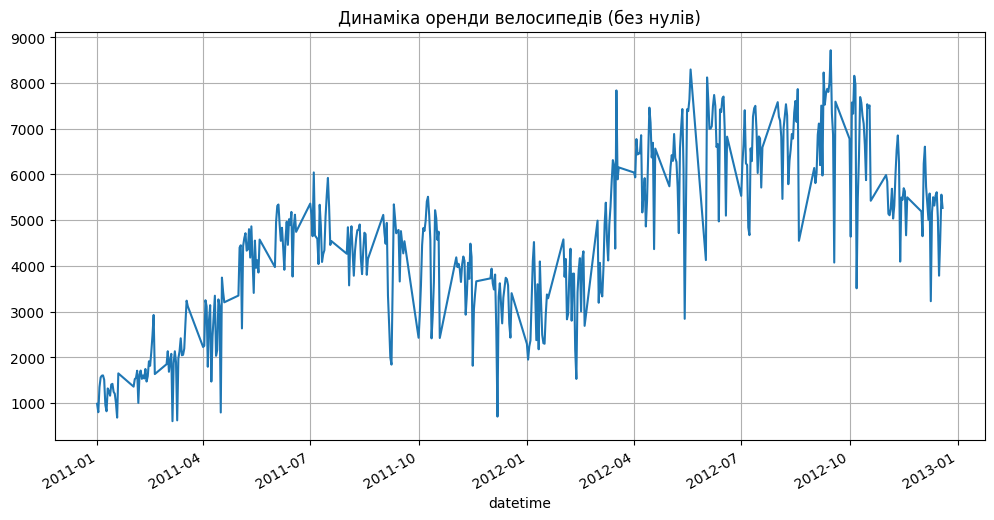

In [35]:
# Ресемплінг поденно та фільтрація нульових значень
count_day = df['count'].resample('d').sum()
count_day = count_day[count_day != 0]

# Побудова графіка без нульових значень
count_day.plot.line(figsize=(12, 6),
                    title="Динаміка оренди велосипедів (без нулів)",
                    grid=True);


1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

  Графік має заломи тому в датафреймі є дані з 1 по 19 число кожного місяця а так як з 20 і по 1 число (виключно) дані приймають значення 0. Для того щоб прибрати заломи знайшов вихід  - виключити дні з нульовими значеннями.
2. Які загальні тенденції ви бачите на графіку?
  Загальні тенденції в тому що компанія почала існування з початку 2011 року і менше ніж за півтора року попит піднявся майже в 2 рази.
3. Чи помітні якісь сезонні коливання?
  Відповідно лінійного графіку можна відмітити сезонні коливання, а саме максимум на попит перепадає з 4 по 10 місяці і це можна пояснити погодніми умовами які дозволяють активно використовувати велосипед.
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?
  Так є періоди з аномальними значеннями - аномалії можуть бути за рахунок погодних умов а також вихідні (святкові) дні.





## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами. Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте сезони не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який сезон найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним сезоном?

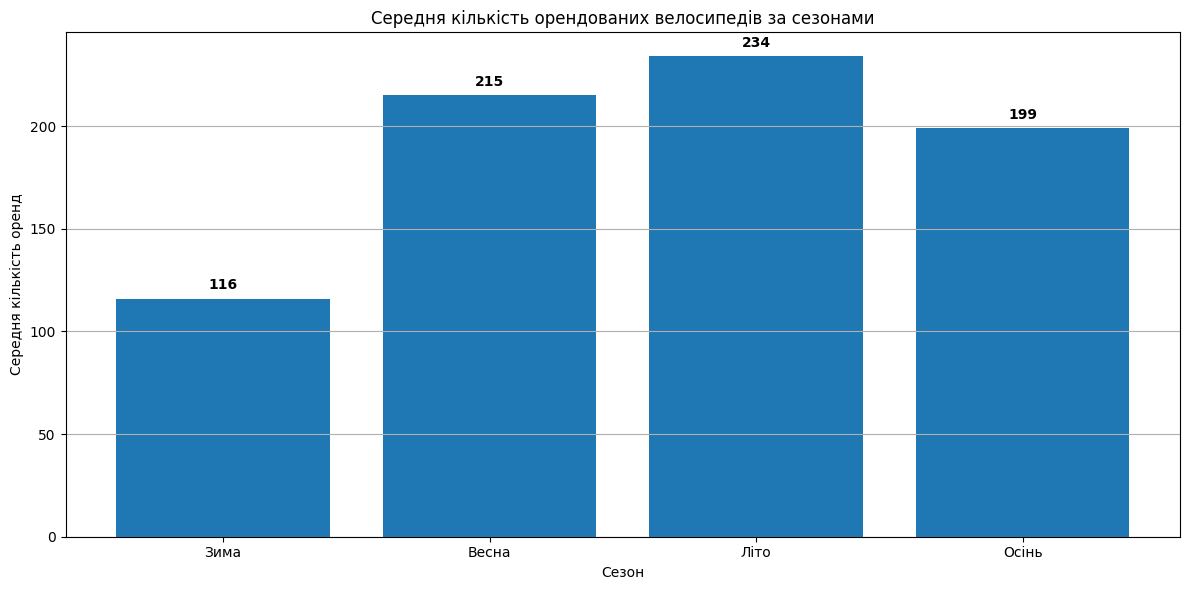

In [36]:
# Назви сезонів (через індекси)
season_names = {1: 'Зима', 2: 'Весна', 3: 'Літо', 4: 'Осінь'}

# Групування даних за сезоном і відразу присвоюємо назви сезони
season_avg = df.groupby('season')['count'].mean().round(0)
season_avg_named = season_avg.rename(index=season_names)

# Побудова графіку
plt.figure(figsize=(12, 6))
bars = plt.bar(season_avg_named.index, season_avg_named.values)

# Підписи над стовпцями
for bar in bars:
   height = bar.get_height()
   plt.text(bar.get_x() + bar.get_width()/2, height + 3, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Оформлення
plt.title('Середня кількість орендованих велосипедів за сезонами')
plt.xlabel('Сезон')
plt.ylabel('Середня кількість оренд')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


  1. В який сезон найбільша середня кількість оренди велосипедів?
  
  Найвищий середній рівень оренди — **влітку**.

  2. Як ви можете пояснити таку сезонну закономірність?  
  Літо — це період теплої погоди, відпусток і тривалих світлих днів. Люди активно гуляють, їздять на природу, займаються спортом — тож велосипед стає популярним засобом пересування і дозвілля.

  3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним сезоном?
  
  Середня кількість влітку — 234 оренд, а взимку — 116.    
  234/116 = у 2 рази більше влітку ніж узимку.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


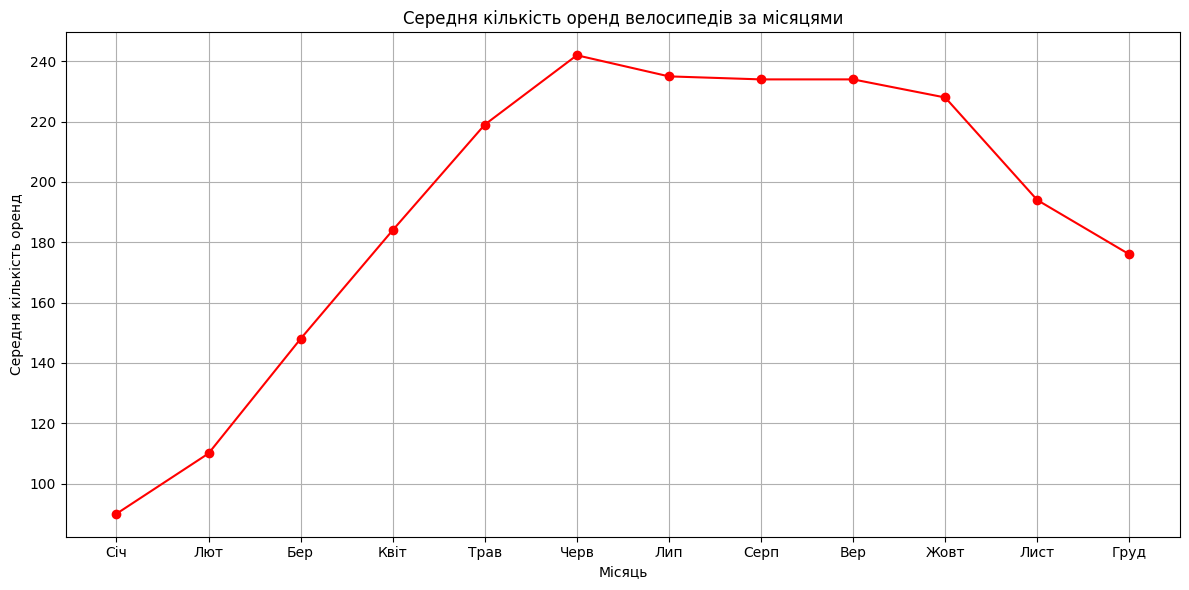

In [37]:
# Групування по місяцях, середнє за всі роки
monthly_avg = df.groupby(df.index.month)['count'].mean().round(0)
monthly_avg
# Створення графіка
monthly_avg.plot(figsize=(12, 6), color='red', marker='o')

# Налаштування осі X: назви місяців
month_names = ['Січ', 'Лют', 'Бер', 'Квіт', 'Трав', 'Черв', 'Лип', 'Серп', 'Вер', 'Жовт', 'Лист', 'Груд']
plt.xticks(ticks=range(1, 13), labels=month_names)

# Оформлення
plt.grid(True)
plt.title('Середня кількість оренд велосипедів за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд'),
plt.tight_layout()
plt.show()


**1. В які місяці спостерігається пік та спад оренди?**  
 Пік оренди — у **літніх місяцях: червень, липень, серпень**.  
 Спад — у **зимових місяцях: грудень, січень, лютий**.

**2. Чи збігається ця закономірність з результатами з попереднього завдання?**  
Так, абсолютно. Сезонний аналіз показав, що **літо — найактивніший сезон**, і щомісячна динаміка підтверджує це: найвищі значення — саме у літні місяці.

**3. Як може вплинути клімат на оренду велосипедів протягом року?**  
- У **теплі місяці** комфортно їздити: багато сонячних днів, суха дорога, довгий день — це сприяє більшій оренді.  
- У **холодні або дощові сезони** оренда падає через дискомфорт, обмерзання доріг, ризик захворіти або слизькі умови.  
- **Вітер, вологість, температура** також впливають: навіть весна з дощами може показати нижчі значення.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму частки днів з різними погодними умовами.
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

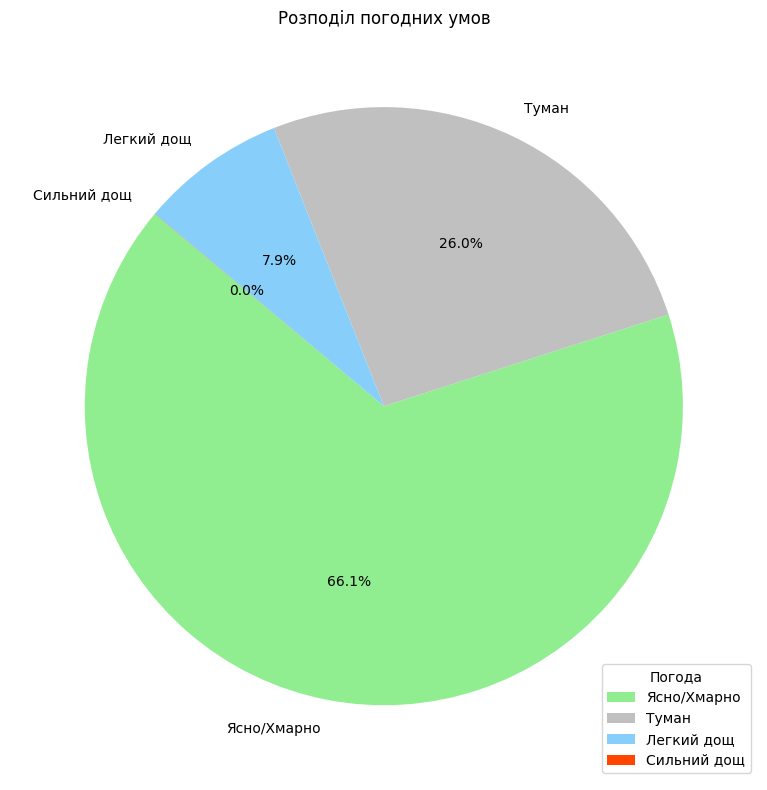

In [38]:
# Назви погодних умов
weather_labels = {1: 'Ясно/Хмарно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'}

# Визначення кольорів для категорій
custom_colors = ['#90ee90', '#c0c0c0', '#87cefa', '#ff4500']  # зелений, сірий, блакитний, червоний

# Підрахунок кількості днів за кожною категорією
weather_counts = df['weather'].value_counts().sort_index()

# Побудова кругової діаграми
plt.figure(figsize=(8, 8))
plt.pie(
    weather_counts,
    labels=[weather_labels[i] for i in weather_counts.index],
    colors=custom_colors,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Розподіл погодних умов')
plt.legend(title="Погода", loc="lower right")
plt.tight_layout()
plt.show()


Яка погода переважає в датасеті?
  Найпоширеніша — ясна / хмарність (1) > 66%.

Чи є дні із сильним дощем? Яка їх частка?
  Такі дні є, але їх дуже мало < 1 %

Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?
  Ясна погода сприяє високій оренді: зручно та безпечно їздити.
  
  Туманна або хмарна — дещо знижує попит, але не критично.  
  
  Дощ або сніг сильно зменшують кількість оренд, особливо для випадкових користувачів.
  
  Сильний дощ практично зупиняє оренду — небезпечно, незручно, мокро.

In [39]:
share_heavy_rain = weather_counts.get(4, 0) / weather_counts.sum() * 100
print(f"Частка днів із сильним дощем: {share_heavy_rain:.3f}%")

Частка днів із сильним дощем: 0.009%


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

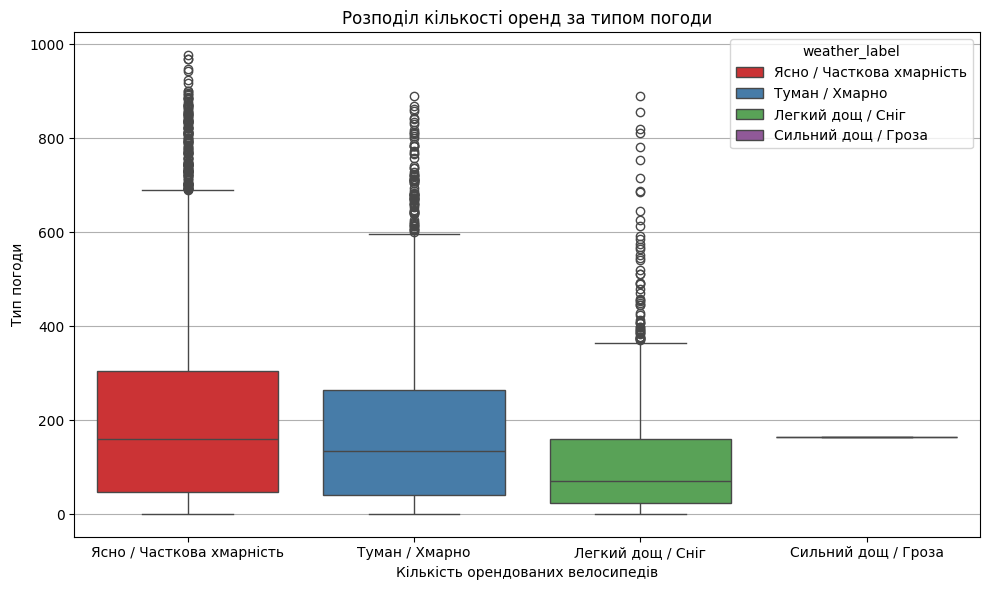

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Переіменування типів погоди
weather_labels = {
    1: 'Ясно / Часткова хмарність',
    2: 'Туман / Хмарно',
    3: 'Легкий дощ / Сніг',
    4: 'Сильний дощ / Гроза'
}
df['weather_label'] = df['weather'].map(weather_labels)

# Створення горизонтального box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='weather_label', y='count', hue='weather_label', palette='Set1', legend=True)


# Оформлення
plt.title('Розподіл кількості оренд за типом погоди')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Тип погоди')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

1. При якій погоді найбільший розкид у кількості оренди? 🔸 Ясна / часткова хмарність — має найбільший розкид: від дуже низьких значень до високих піків. Це логічно, бо така погода найчастіше і найбільш варіативна за днями (наприклад, будні проти вихідних).

2. Чи є викиди (outliers) в даних? При якій погоді? 🟠 Так!

Найбільше викидів також спостерігається при ясній погоді — ці точки показують дні з аномально високою орендою (можливо, свята, акції чи особливо сприятливі умови).

При тумані та легкому дощі кількість викидів значно менша, але вони теж є.

3. При якій погоді медіанне значення оренди найвище? 🔺 Найвища медіана — при ясній погоді. Це підтверджує, що більшість оренд відбувається у сприятливі дні.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

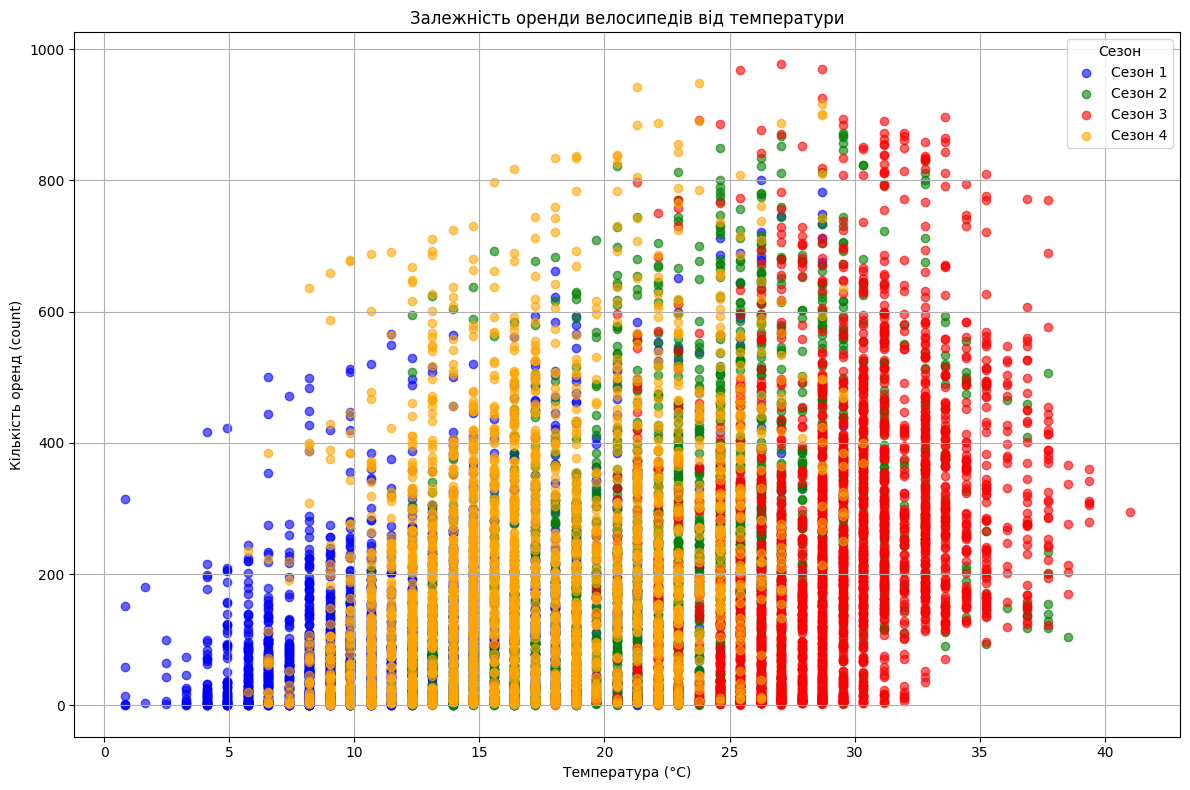

In [41]:
# Колірна палітра для сезонів
season_colors = {
    1: 'blue',   # зима
    2: 'green',     # весна
    3: 'red',     # літо
    4: 'orange'     # осінь
}

# Побудова графіку
plt.figure(figsize=(12, 8))

# Діаграма розсіювання з кольором за сезонами
for season in sorted(df['season'].unique()):
    plt.scatter(
        df[df['season'] == season]['temp'],
        df[df['season'] == season]['count'],
        label=f'Сезон {season}',
        color=season_colors[season],
        alpha=0.6
    )

plt.title('Залежність оренди велосипедів від температури')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренд (count)')
plt.legend(title='Сезон')
plt.grid(True)
plt.tight_layout()
plt.show()

**Чи є зв’язок між температурою та кількістю оренди?**
  
  Так, існує помітний позитивний зв’язок.
Коли температура зростає (особливо в межах 15–30°C), кількість оренд велосипедів також зростає. Це логічно, адже люди більше користуються велосипедами в комфортну погоду.

  При низьких або дуже високих температурах — оренда знижується.
Низькі температури взимку або надмірна спека можуть зменшити попит.

## Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

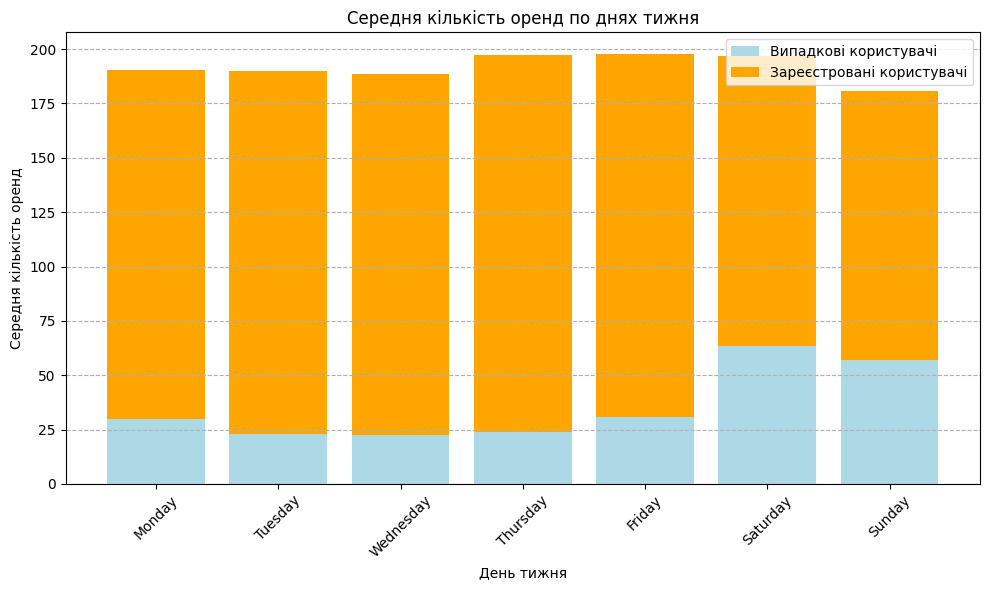

In [43]:
# Групування по дням тижня
avg_users = df.groupby('weekday')[['casual', 'registered']].mean()

# Щоб дні були у правильному порядку:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_users = avg_users.loc[weekday_order]

# Побудова stacked bar chart
plt.figure(figsize=(10, 6))
plt.bar(avg_users.index, avg_users['casual'], label='Випадкові користувачі', color='lightblue')
plt.bar(avg_users.index, avg_users['registered'], bottom=avg_users['casual'], label='Зареєстровані користувачі', color='orange')

plt.title('Середня кількість оренд по днях тижня')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

Питання для інтерпретації:

В які дні тижня більше оренд від зареєстрованих користувачів?
найбільш оренди  перепадає на четвер, пятниця та субота

Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?
це пояснює тим що з понеділка по середу люди більш завантажені робочими процесами а ближче до вихідних починають оренду щоб вихідні дні провести відпочиваючи велопрогулянками. а чому саме зареєстровані та тому що зареєстровані користувачі можуть завчасно забронювати (замовити ) оренду велосипедів.